In [1]:
import torch
from torch import nn 
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
train_data = datasets.CIFAR10(
    root='data',
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None)

test_data = datasets.CIFAR10(
    root='data',
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None)

In [3]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [4]:
type(train_data)

torchvision.datasets.cifar.CIFAR10

In [5]:
type(train_data[0])

tuple

In [6]:
image, label = train_data[0]

In [7]:
image

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [8]:
label

6

In [9]:
image.shape

torch.Size([3, 32, 32])

In [10]:
len(train_data)

50000

In [11]:
len(test_data)

10000

In [12]:
class_names = train_data.classes

In [13]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [14]:
len(class_names)

10

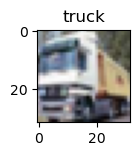

In [15]:
image, label = train_data[1]
image = image.permute(1,2,0)
plt.figure(figsize=(1.2,1.2))
plt.imshow(image)
plt.title(class_names[label])
plt.show()

In [16]:
from torchvision import transforms

In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.491, 0.482, 0.446],
                         std=[0.247, 0.243, 0.261])
])

train_data = datasets.CIFAR10(
    root='data',
    train=True,
    download=True,
    transform=transform,
    target_transform=None)

test_data = datasets.CIFAR10(
    root='data',
    train=False,
    download=True,
    transform=transform,
    target_transform=None)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9084703..2.10758].


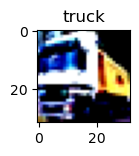

In [18]:
image, label = train_data[1]
image = image.permute(1,2,0)
plt.figure(figsize=(1.2,1.2))
plt.imshow(image)
plt.title(class_names[label])
plt.show()

In [19]:
from torch.utils.data import DataLoader

In [20]:
torch.manual_seed(42)
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

In [21]:
len(train_dataloader) , len(test_dataloader) # toplam batch sayisi

(1563, 313)

In [22]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.446], std=[0.247, 0.243, 0.261])
           )

In [23]:
train_dataloader.dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.446], std=[0.247, 0.243, 0.261])
           )

In [24]:
train_dataloader.dataset[0][0].shape

torch.Size([3, 32, 32])

In [25]:
flatten_model = nn.Flatten()

first_data = train_dataloader.dataset[0][0]
flattened_data = flatten_model(first_data)

first_data.shape, flattened_data.shape

(torch.Size([3, 32, 32]), torch.Size([3, 1024]))

In [26]:
class CIFAR10Classifier(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

In [27]:
first_data.shape

torch.Size([3, 32, 32])

In [28]:
3*32*32 # tane feature miz var

3072

In [29]:
len(class_names)

10

In [30]:
torch.manual_seed(42)

model_0 = CIFAR10Classifier(
    input_shape=3072,
    hidden_units=32,
    output_shape=len(class_names)
)

In [31]:
model_0 = torch.compile(model_0)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(), lr = 0.001)

In [32]:
def calculate_accuracy(y_pred, y_true): # (Önce tahmin, sonra gerçek)
    # 1. Doğru tahminleri topla ve Python sayısına (.item) çevir
    correct = torch.eq(y_true, y_pred).sum().item()
    # 2. (Doğru Sayısı / Toplam Sayı) * 100
    acc = (correct / len(y_true)) * 100
    return acc
#------------------------------------------
# def calculate_accuracy(y_pred, y_true):
#     correct = (y_true == y_pred).sum().item()
#     return (correct / len(y_true)) * 100


In [33]:
epochs = 10

for epoch in range(epochs):
    ## training
    train_loss = 0
    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()
        y_pred = model_0(X)#forward pass
        loss = loss_fn(y_pred, y) #İşlem sırasını hep "Önce model ne dedi, sonra gerçekte neydi?":(tahmin, gerçek).
        train_loss+=loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 == 0:
            print(f"Batch number -> {batch}")
    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0, 0 
    model_0.eval()
    with torch.inference_mode():
        for (X,y) in test_dataloader:
            test_pred = model_0(X)
            test_loss += loss_fn(test_pred, y)

            test_acc += calculate_accuracy(y_pred=test_pred.argmax(dim=1) , y_true = y)
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
        
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")


Batch number -> 0
Batch number -> 500
Batch number -> 1000
Batch number -> 1500

Train loss: 1.85191 | Test loss: 1.79191, Test acc: 36.99%

Batch number -> 0
Batch number -> 500
Batch number -> 1000
Batch number -> 1500

Train loss: 1.75902 | Test loss: 1.76013, Test acc: 38.76%

Batch number -> 0
Batch number -> 500
Batch number -> 1000
Batch number -> 1500

Train loss: 1.74537 | Test loss: 1.78375, Test acc: 36.98%

Batch number -> 0
Batch number -> 500
Batch number -> 1000
Batch number -> 1500

Train loss: 1.73209 | Test loss: 1.74089, Test acc: 39.62%

Batch number -> 0
Batch number -> 500
Batch number -> 1000
Batch number -> 1500

Train loss: 1.72518 | Test loss: 1.75660, Test acc: 38.70%

Batch number -> 0
Batch number -> 500
Batch number -> 1000
Batch number -> 1500

Train loss: 1.71680 | Test loss: 1.74996, Test acc: 39.51%

Batch number -> 0
Batch number -> 500
Batch number -> 1000
Batch number -> 1500

Train loss: 1.71219 | Test loss: 1.76109, Test acc: 39.30%

Batch number 

In [34]:
def evaluate_model_performance(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, accuracy_function):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_function(y_pred = y_pred.argmax(dim=1),y_true=y)
        loss = loss / len(data_loader)
        acc = acc / len(data_loader)
    
    return {"model_name": getattr(model, "_orig_mod", model).__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

In [35]:
model_0_results = evaluate_model_performance(model = model_0,
                                             data_loader=test_dataloader,
                                             loss_fn=loss_fn,
                                             accuracy_function=calculate_accuracy)

In [36]:
import pandas as pd
compare = pd.DataFrame([model_0_results])
print(compare)

          model_name  model_loss  model_acc
0  CIFAR10Classifier    1.770783  38.518371


In [37]:
class CIFAR10ClassifierNonLinear(nn.Module):
    
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

In [38]:
torch.manual_seed(42)
model_1 = CIFAR10ClassifierNonLinear(input_shape=3072,
                                    hidden_units=32,
                                    output_shape=len(class_names))

In [39]:
model_1 = torch.compile(model_1)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr = 0.001)

In [40]:
epochs = 10

for epoch in range(epochs):
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        model_1.train()
        y_pred = model_1(X)
        loss=loss_fn(y_pred, y)
        train_loss+=loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 == 0:
            print(f"Batch -> {batch}")
    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0,0
    model_1.eval()
    with torch.inference_mode():
        for (X,y) in test_dataloader:
            test_pred = model_1(X)
            test_loss += loss_fn(test_pred,y)
            test_acc += calculate_accuracy(y_pred = test_pred.argmax(dim=1),y_true=y)
        
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)  

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.72454 | Test loss: 1.61981, Test acc: 43.43%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.54965 | Test loss: 1.55594, Test acc: 44.38%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.49986 | Test loss: 1.56207, Test acc: 45.39%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.45863 | Test loss: 1.51489, Test acc: 47.08%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.43132 | Test loss: 1.51807, Test acc: 46.44%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.40682 | Test loss: 1.52366, Test acc: 46.03%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.38763 | Test loss: 1.52100, Test acc: 46.95%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.37032 | Test loss: 1.49082, Test acc: 47.61%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.35379 | Test loss: 1.48664, T

In [41]:
model_1_results = evaluate_model_performance(model = model_1,
                                             data_loader=test_dataloader,
                                             loss_fn=loss_fn,
                                             accuracy_function=calculate_accuracy)

In [42]:
compare = pd.DataFrame([model_0_results, model_1_results])
print(compare)

                   model_name  model_loss  model_acc
0           CIFAR10Classifier    1.770783  38.518371
1  CIFAR10ClassifierNonLinear    1.498435  47.943291


In [43]:
class CIFAR10ClassifierCNN(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3,
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block_2 = nn.Sequential(
           nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units, 
                      kernel_size=3,
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        #dense layer
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*8*8, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        return self.classifier(self.block_2(self.block_1(x)))

In [44]:
torch.manual_seed(42)

model_2 = CIFAR10ClassifierCNN(input_shape=3,
                               hidden_units=32,
                               output_shape=len(class_names))

In [45]:
model_2

CIFAR10ClassifierCNN(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)

In [46]:
8*8*32

2048

In [47]:
#model_2 = torch.compile(model_2)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), lr = 0.001)

In [48]:
epochs = 10

for epoch in range(epochs):
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        model_2.train()
        y_pred = model_2(X)
        loss=loss_fn(y_pred, y)
        train_loss+=loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 == 0:
            print(f"Batch -> {batch}")
    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0,0
    model_2.eval()
    with torch.inference_mode():
        for (X,y) in test_dataloader:
            test_pred = model_2(X)
            test_loss += loss_fn(test_pred,y)
            test_acc += calculate_accuracy(y_pred = test_pred.argmax(dim=1),y_true=y)
        
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)  

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 1.32378 | Test loss: 1.00459, Test acc: 64.69%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 0.90681 | Test loss: 0.85741, Test acc: 69.75%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 0.77313 | Test loss: 0.82305, Test acc: 71.93%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 0.69948 | Test loss: 0.77309, Test acc: 73.25%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 0.63489 | Test loss: 0.80617, Test acc: 72.87%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 0.59545 | Test loss: 0.78082, Test acc: 73.59%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 0.55302 | Test loss: 0.82475, Test acc: 72.62%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 0.52042 | Test loss: 0.79421, Test acc: 74.12%

Batch -> 0
Batch -> 500
Batch -> 1000
Batch -> 1500

Train loss: 0.49445 | Test loss: 0.83501, T

In [98]:
model_2_results = evaluate_model_performance(model = model_2,
                                             data_loader=test_dataloader,
                                             loss_fn=loss_fn,
                                             accuracy_function=calculate_accuracy)

In [100]:
compare = pd.DataFrame([model_0_results, model_1_results, model_2_results])
print(compare)

                   model_name  model_loss  model_acc
0           CIFAR10Classifier    1.770783  38.518371
1  CIFAR10ClassifierNonLinear    1.498435  47.943291
2        CIFAR10ClassifierCNN    0.840614  74.540735


In [102]:
# with the working CNN, lr = 0.001 gives better accuracy

In [104]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [106]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8060195..2.1226053].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9351246..1.9703058].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6607763..1.425657].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8925935..1.927278].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0670002..2.1316872].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9835391..2.1226053].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8767167.

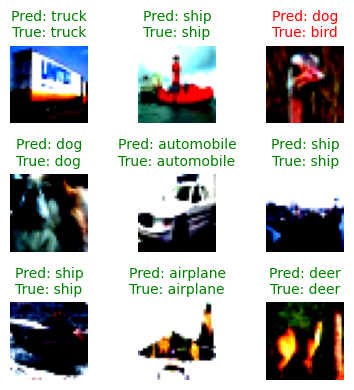

In [122]:
show_random_predictions(model_2, test_data, class_names)